# 05B · Evaluación del escenario de siniestros con víctimas
### Fase 5 de CRISP-DM · modelo ajustado

Este notebook evalúa el **Random Forest ajustado** mediante validación temporal en 2018–2022 y confirmado retrospectivamente en 2023–2024. El umbral 0,52 se seleccionó con predicciones fuera de muestra de 2020–2022. Se conserva el Random Forest base como referencia y no se reentrena ni sobrescribe ningún modelo.

## Alcance

La evaluación 2023–2024 es retrospectiva: esos años ya fueron inspeccionados durante el desarrollo. La etiqueta es híbrida: en 49 de 80 combinaciones localidad–franja, `Alto_Riesgo=1` significa que ocurrió al menos un siniestro con víctimas; en 28 exige dos o más y en tres exige tres o más. Las métricas evalúan predicción respecto a esta etiqueta, no peligrosidad causal ni riesgo individual.

## 1. Importación y configuración

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
DATA_FILE = Path('../data/processed/dataset_victimas_localidad_franja_fecha.parquet')
MODELS_PATH = Path('../models/victimas')
REPORTS_PATH = Path('../reports/evaluation_victimas')
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 2. Datos y artefactos

In [2]:
dataset = pd.read_parquet(DATA_FILE)
dataset['Fecha_Acc'] = pd.to_datetime(dataset['Fecha_Acc'])
base_metadata = json.loads((MODELS_PATH / 'metadata_modelo.json').read_text(encoding='utf-8'))
tuned_metadata = json.loads((MODELS_PATH / 'metadata_random_forest_ajustado.json').read_text(encoding='utf-8'))
feature_cols = base_metadata['variables']
selected_model = 'Random Forest ajustado'
selected_threshold = float(tuned_metadata['umbral_temporal'])
base_threshold = float(base_metadata['umbral_candidato'])
pipelines = {
    'Regresión Logística': joblib.load(MODELS_PATH / 'pipeline_logistica_victimas.pkl'),
    'Random Forest base': joblib.load(MODELS_PATH / 'pipeline_random_forest_victimas.pkl'),
    'Random Forest ajustado': joblib.load(MODELS_PATH / 'pipeline_random_forest_ajustado_victimas.pkl'),
    'XGBoost': joblib.load(MODELS_PATH / 'pipeline_xgboost_victimas.pkl'),
}
required = feature_cols + ['Fecha_Acc', 'Localidad', 'Franja_Horaria', 'Periodo', 'Alto_Riesgo']
assert dataset[required].isna().sum().sum() == 0
assert tuned_metadata['seleccion_sin_test'] is True
print('Modelo evaluado:', selected_model, '| Umbral temporal:', selected_threshold)
print('Hiperparámetros:', tuned_metadata['hiperparametros'])
print('Dataset:', dataset.shape)

Modelo evaluado: Random Forest ajustado | Umbral temporal: 0.5199999999999999
Hiperparámetros: {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'class_weight': 'balanced'}
Dataset: (204560, 16)


In [3]:
test = dataset[dataset.Periodo.eq('test')].copy()
test['Anio'] = test.Fecha_Acc.dt.year
X_test, y_test = test[feature_cols], test.Alto_Riesgo.astype(int)
scores = {name: pipeline.predict_proba(X_test)[:, 1] for name, pipeline in pipelines.items()}
thresholds = {
    'Regresión Logística': 0.5,
    'Random Forest base': base_threshold,
    'Random Forest ajustado': selected_threshold,
    'XGBoost': 0.5,
}
predictions = {name: (scores[name] >= thresholds[name]).astype(int) for name in pipelines}
print(f'Test: {len(test):,} observaciones; prevalencia={y_test.mean():.2%}')

Test: 58,480 observaciones; prevalencia=19.01%


## 3. Métricas globales

In [4]:
def classification_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'AUC_ROC': roc_auc_score(y_true, y_score),
        'Average_Precision': average_precision_score(y_true, y_score),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'Especificidad': tn / (tn + fp),
        'Balanced_Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Brier': brier_score_loss(y_true, y_score),
        'Tasa_Predicha_Positiva': np.mean(y_pred),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

global_metrics = pd.DataFrame([
    {'Modelo': name, 'Umbral': thresholds[name],
     **classification_metrics(y_test, predictions[name], scores[name])}
    for name in pipelines
]).sort_values('Average_Precision', ascending=False)
global_metrics.to_csv(REPORTS_PATH / 'metricas_globales.csv', index=False, encoding='utf-8-sig')

rf_comparison = global_metrics[global_metrics.Modelo.isin(['Random Forest base', selected_model])].set_index('Modelo')
rf_delta = (rf_comparison.loc[selected_model] - rf_comparison.loc['Random Forest base']).rename('Cambio_Ajustado_Menos_Base')
rf_delta.to_frame().to_csv(REPORTS_PATH / 'comparacion_random_forest_ajustado_vs_base.csv', encoding='utf-8-sig')
display(global_metrics.round(4))
display(rf_delta[['F1','AUC_ROC','Average_Precision','Precision','Recall','Brier','FP','FN','TP']].to_frame().T.round(4))

,Modelo,Umbral,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
2,Random Forest ajustado,0.52,0.4058,0.6933,0.3098,0.2941,0.6544,0.6312,0.6428,0.2221,0.4231,29895,17467,3842,7276
1,Random Forest base,0.55,0.3982,0.6853,0.3038,0.3011,0.5877,0.6797,0.6337,0.2304,0.3711,32194,15168,4584,6534
3,XGBoost,0.50,0.3937,0.6800,0.3020,0.2793,0.6670,0.5960,0.6315,0.2228,0.4540,28226,19136,3702,7416
0,Regresión Logística,0.50,0.3633,0.6411,0.2702,0.2452,0.7004,0.4940,0.5972,0.2383,0.5430,23395,23967,3331,7787


,F1,AUC_ROC,Average_Precision,Precision,Recall,Brier,FP,FN,TP
Cambio_Ajustado_Menos_Base,0.0076,0.008,0.006,-0.007,0.0667,-0.0083,2299.0,-742.0,742.0


## 4. Matrices de confusión

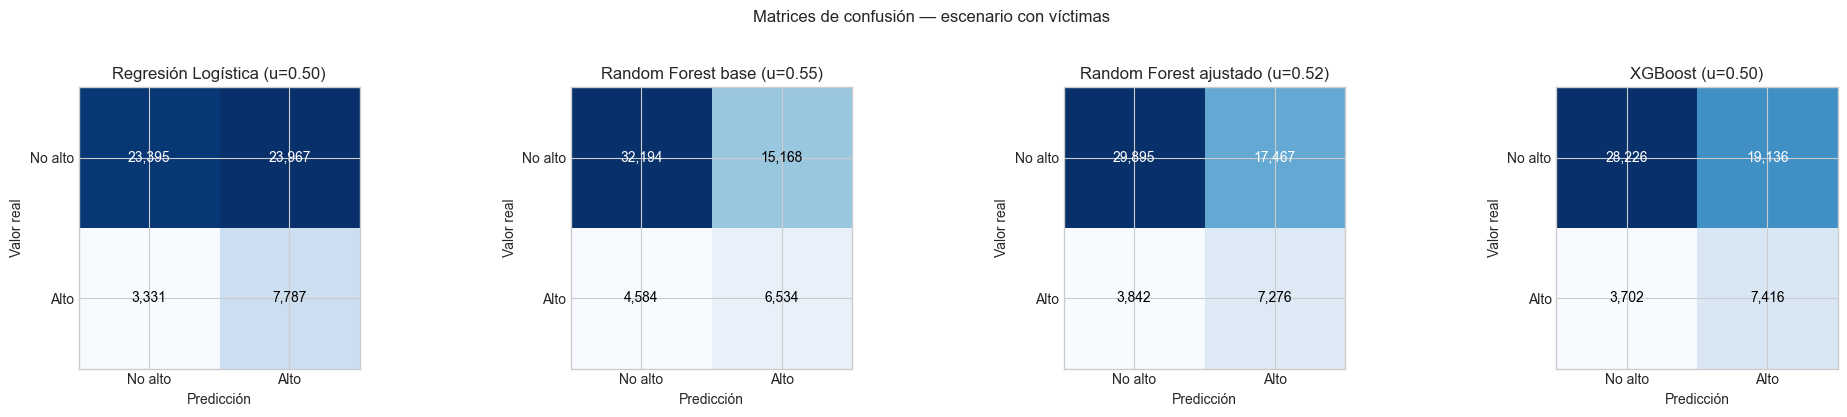

In [5]:
model_names = list(pipelines)
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))
for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, predictions[name], labels=[0, 1])
    ax.imshow(cm, cmap='Blues')
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f'{cm[row, col]:,}', ha='center', va='center',
                    color='white' if cm[row, col] > cm.max()/2 else 'black')
    ax.set(title=f'{name} (u={thresholds[name]:.2f})', xlabel='Predicción', ylabel='Valor real')
    ax.set_xticks([0, 1], ['No alto', 'Alto']); ax.set_yticks([0, 1], ['No alto', 'Alto'])
plt.suptitle('Matrices de confusión — escenario con víctimas', y=1.03)
plt.tight_layout(); plt.savefig(REPORTS_PATH / '01_matrices_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Curvas ROC y Precision-Recall

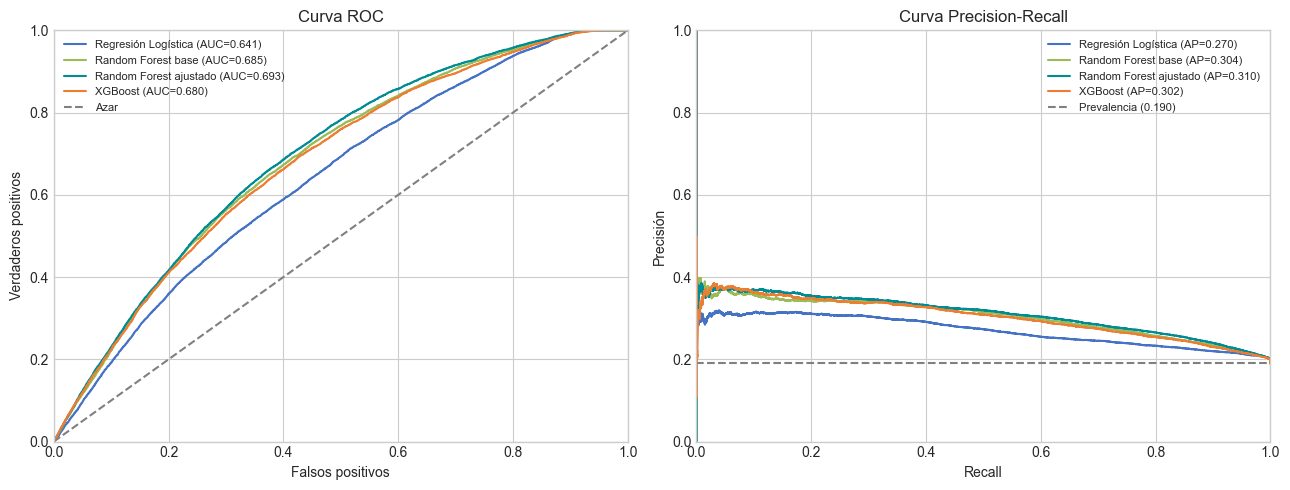

In [6]:
colors = {'Regresión Logística': '#4472C4', 'Random Forest base': '#9BBB59', 'Random Forest ajustado': '#008C95', 'XGBoost': '#ED7D31'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in model_names:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    precision, recall, _ = precision_recall_curve(y_test, scores[name])
    axes[0].plot(fpr, tpr, color=colors[name], label=f'{name} (AUC={roc_auc_score(y_test, scores[name]):.3f})')
    axes[1].plot(recall, precision, color=colors[name], label=f'{name} (AP={average_precision_score(y_test, scores[name]):.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Azar')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Prevalencia ({y_test.mean():.3f})')
axes[0].set(title='Curva ROC', xlabel='Falsos positivos', ylabel='Verdaderos positivos')
axes[1].set(title='Curva Precision-Recall', xlabel='Recall', ylabel='Precisión')
for ax in axes: ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(REPORTS_PATH / '02_curvas_roc_pr.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Calibración

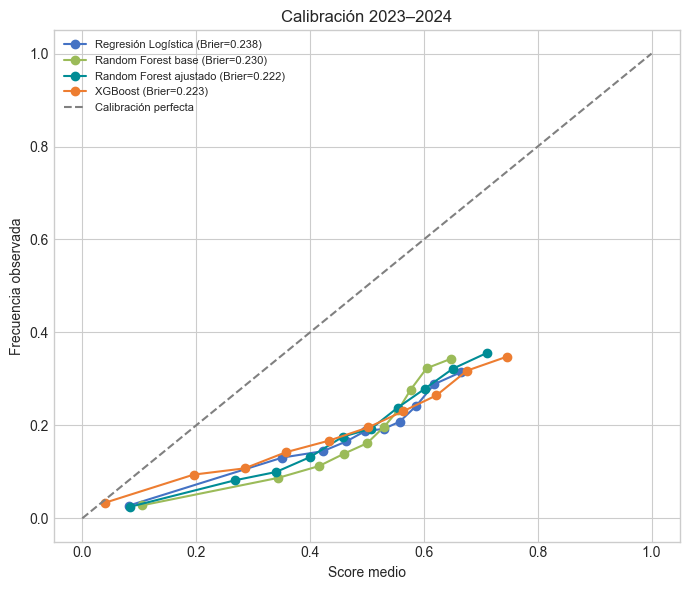

,Modelo,Grupo,Score_Medio,Frecuencia_Observada,Observaciones
0,Regresión Logística,0,0.0816,0.0274,5848
1,Regresión Logística,1,0.3517,0.1308,5848
2,Regresión Logística,2,0.4227,0.1445,5848
3,Regresión Logística,3,0.4636,0.1654,5848
4,Regresión Logística,4,0.4975,0.1881,5848
5,Regresión Logística,5,0.5292,0.1922,5848
6,Regresión Logística,6,0.5575,0.2079,5848
7,Regresión Logística,7,0.5863,0.2415,5848
8,Regresión Logística,8,0.6183,0.2886,5848
9,Regresión Logística,9,0.6657,0.3148,5848


In [7]:
calibration_rows = []
plt.figure(figsize=(7, 6))
for name in model_names:
    observed, predicted = calibration_curve(y_test, scores[name], n_bins=10, strategy='quantile')
    plt.plot(predicted, observed, marker='o', color=colors[name],
             label=f'{name} (Brier={brier_score_loss(y_test, scores[name]):.3f})')
    ranks = pd.qcut(pd.Series(scores[name]), q=10, labels=False, duplicates='drop')
    temp = pd.DataFrame({'Grupo': ranks, 'Score': scores[name], 'Real': y_test.to_numpy()})
    grouped = temp.groupby('Grupo').agg(Score_Medio=('Score','mean'),
                                         Frecuencia_Observada=('Real','mean'), Observaciones=('Real','size')).reset_index()
    grouped.insert(0, 'Modelo', name); calibration_rows.append(grouped)
plt.plot([0,1], [0,1], '--', color='gray', label='Calibración perfecta')
plt.xlabel('Score medio'); plt.ylabel('Frecuencia observada'); plt.title('Calibración 2023–2024')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(REPORTS_PATH / '03_calibracion.png', dpi=160, bbox_inches='tight'); plt.show()
calibration_table = pd.concat(calibration_rows, ignore_index=True)
calibration_table.to_csv(REPORTS_PATH / 'calibracion_por_deciles.csv', index=False, encoding='utf-8-sig')
calibration_table.round(4)

Los modelos utilizan balanceo de clases; por ello `predict_proba` no debe asumirse automáticamente como una probabilidad calibrada. Si la curva se aleja de la diagonal, el dashboard debe presentar puntuaciones relativas o niveles de priorización.

## 7. Estabilidad entre 2023 y 2024

In [8]:
year_rows = []
for year in [2023, 2024]:
    mask = test.Anio.eq(year).to_numpy()
    for name in model_names:
        year_rows.append({'Anio': year, 'Modelo': name, 'Umbral': thresholds[name],
                          **classification_metrics(y_test.to_numpy()[mask], predictions[name][mask], scores[name][mask])})
year_metrics = pd.DataFrame(year_rows)
year_metrics.to_csv(REPORTS_PATH / 'metricas_por_anio.csv', index=False, encoding='utf-8-sig')
year_metrics[['Anio','Modelo','F1','AUC_ROC','Average_Precision','Precision','Recall','Brier']].round(4)

,Anio,Modelo,F1,AUC_ROC,Average_Precision,Precision,Recall,Brier
0,2023,Regresión Logística,0.3620,0.6413,0.2700,0.2440,0.7017,0.2384
1,2023,Random Forest base,0.3981,0.6866,0.3047,0.3008,0.5884,0.2296
2,2023,Random Forest ajustado,0.4044,0.6935,0.3100,0.2935,0.6500,0.2219
3,2023,XGBoost,0.3911,0.6808,0.3052,0.2771,0.6645,0.2230
4,2024,Regresión Logística,0.3645,0.6408,0.2706,0.2465,0.6991,0.2382
5,2024,Random Forest base,0.3983,0.6841,0.3032,0.3014,0.5870,0.2312
6,2024,Random Forest ajustado,0.4071,0.6932,0.3101,0.2946,0.6588,0.2223
7,2024,XGBoost,0.3964,0.6793,0.2993,0.2815,0.6695,0.2225


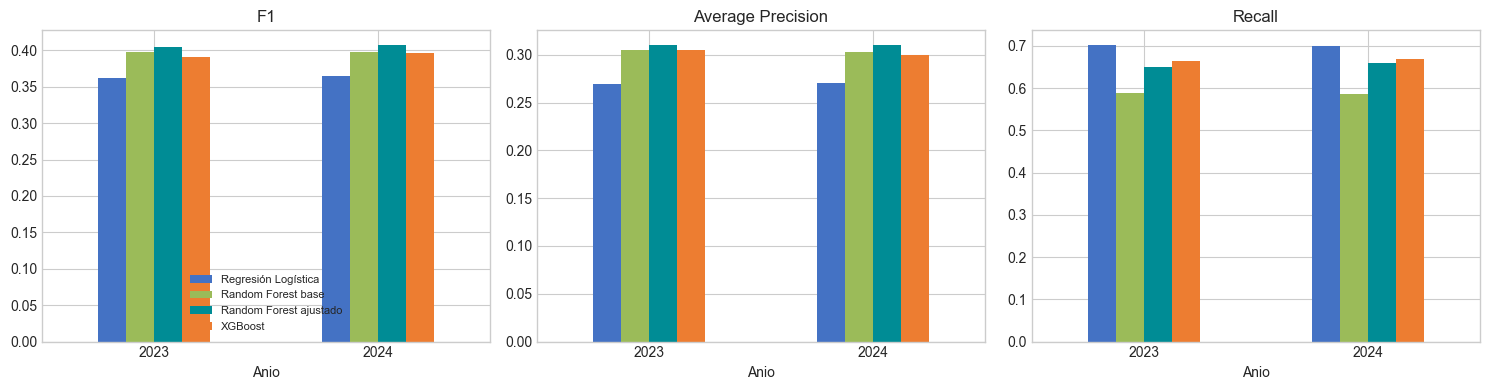

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['F1','Average_Precision','Recall']):
    pivot = year_metrics.pivot(index='Anio', columns='Modelo', values=metric)
    pivot[model_names].plot(kind='bar', ax=ax, color=[colors[n] for n in model_names])
    ax.set_title(metric.replace('_',' ')); ax.tick_params(axis='x', rotation=0)
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(fontsize=8); plt.tight_layout()
plt.savefig(REPORTS_PATH / '04_metricas_por_anio.png', dpi=160, bbox_inches='tight'); plt.show()

## 8. Errores del Random Forest ajustado por localidad y franja

In [10]:
rf_eval = test[['Fecha_Acc','Anio','Localidad','Franja_Horaria','Alto_Riesgo']].copy()
rf_eval['Score'] = scores[selected_model]
rf_eval['Prediccion'] = predictions[selected_model]

def subgroup_metrics(frame, column):
    rows = []
    for value, part in frame.groupby(column):
        result = classification_metrics(part.Alto_Riesgo, part.Prediccion, part.Score)
        rows.append({column: value, 'Observaciones': len(part), 'Positivos': int(part.Alto_Riesgo.sum()),
                     'Prevalencia': part.Alto_Riesgo.mean(), **result})
    return pd.DataFrame(rows)

by_locality = subgroup_metrics(rf_eval, 'Localidad').sort_values('F1', ascending=False)
by_slot = subgroup_metrics(rf_eval, 'Franja_Horaria').sort_values('F1', ascending=False)
by_locality.to_csv(REPORTS_PATH / 'metricas_random_forest_ajustado_por_localidad.csv', index=False, encoding='utf-8-sig')
by_slot.to_csv(REPORTS_PATH / 'metricas_random_forest_ajustado_por_franja.csv', index=False, encoding='utf-8-sig')
display(by_locality.round(4)); display(by_slot.round(4))

,Localidad,Observaciones,Positivos,Prevalencia,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
13,SANTA FE,2924,832,0.2845,0.4834,0.6206,0.3536,0.3405,0.8329,0.3585,0.5957,0.2803,0.6960,750,1342,139,693
9,LOS MÁRTIRES,2924,762,0.2606,0.4696,0.6474,0.3405,0.3312,0.8071,0.4255,0.6163,0.2784,0.6351,920,1242,147,615
11,RAFAEL URIBE URIBE,2924,641,0.2192,0.4597,0.6961,0.3494,0.3436,0.6942,0.6277,0.6610,0.2332,0.4429,1433,850,196,445
4,CHAPINERO,2924,758,0.2592,0.4557,0.6256,0.3345,0.3093,0.8654,0.3236,0.5945,0.2902,0.7254,701,1465,102,656
19,USME,2924,768,0.2627,0.4494,0.6017,0.3156,0.3093,0.8216,0.3465,0.5840,0.2648,0.6977,747,1409,137,631
6,ENGATIVÁ,2924,775,0.2650,0.4416,0.6081,0.3387,0.2975,0.8568,0.2704,0.5636,0.2949,0.7633,581,1568,111,664
17,TUNJUELITO,2924,713,0.2438,0.4232,0.6217,0.3221,0.2837,0.8331,0.3216,0.5773,0.2942,0.7161,711,1500,119,594
18,USAQUÉN,2924,616,0.2107,0.4152,0.6742,0.3474,0.3163,0.6039,0.6516,0.6278,0.2393,0.4022,1504,804,244,372
14,SUBA,2924,724,0.2476,0.4106,0.5940,0.3005,0.2879,0.7155,0.4177,0.5666,0.2688,0.6153,919,1281,206,518
12,SAN CRISTÓBAL,2924,481,0.1645,0.4084,0.7007,0.3139,0.3427,0.5052,0.8093,0.6572,0.1952,0.2425,1977,466,238,243


,Franja_Horaria,Observaciones,Positivos,Prevalencia,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP
2,Noche,14620,3292,0.2252,0.4306,0.6646,0.3284,0.3029,0.7442,0.5023,0.6233,0.2486,0.5532,5690,5638,842,2450
1,Mañana,14620,2885,0.1973,0.4262,0.7058,0.3266,0.2980,0.7480,0.5668,0.6574,0.2305,0.4953,6651,5084,727,2158
3,Tarde,14620,2623,0.1794,0.3957,0.6977,0.2935,0.2810,0.6687,0.6259,0.6473,0.2179,0.4269,7509,4488,869,1754
0,Madrugada,14620,2318,0.1585,0.3330,0.6749,0.2737,0.2882,0.3943,0.8165,0.6054,0.1913,0.2169,10045,2257,1404,914


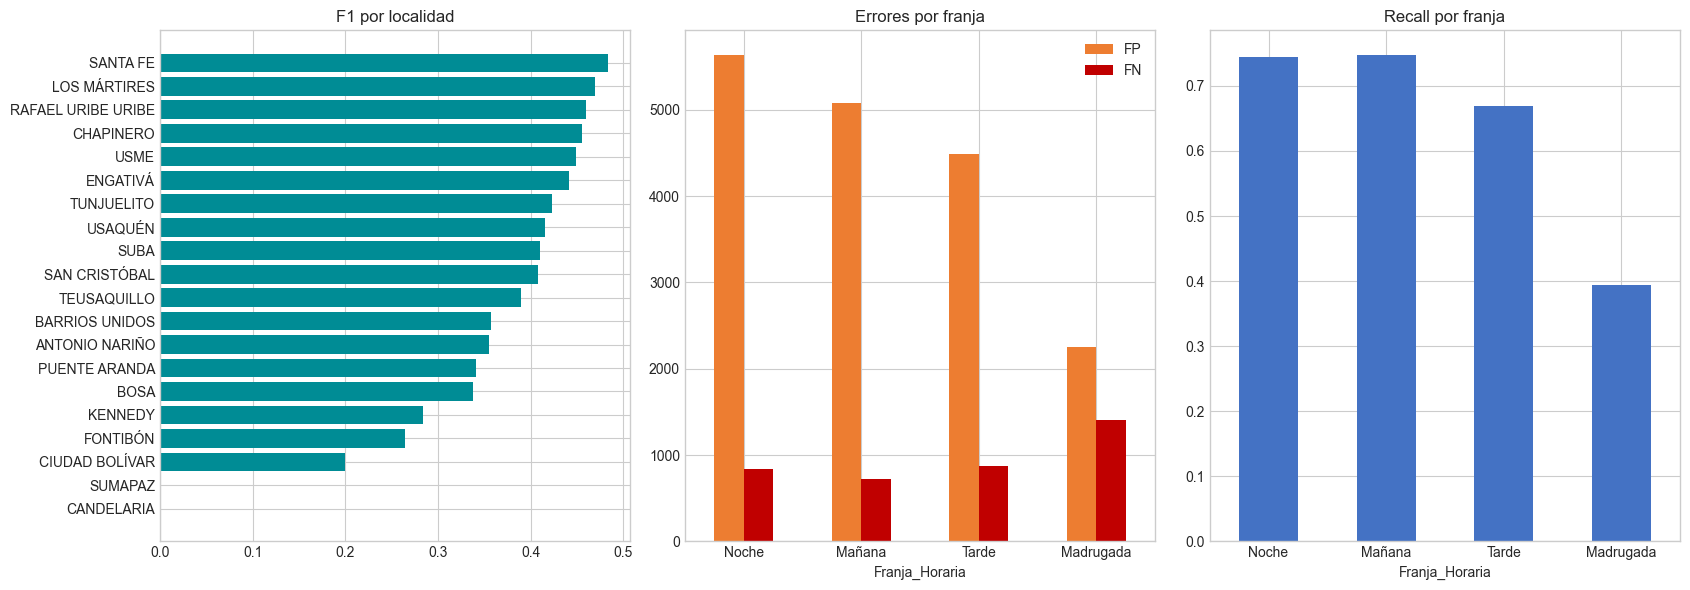

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
loc_plot = by_locality.sort_values('F1')
axes[0].barh(loc_plot.Localidad, loc_plot.F1, color='#008C95'); axes[0].set_title('F1 por localidad')
slot_plot = by_slot.set_index('Franja_Horaria')
slot_plot[['FP','FN']].plot(kind='bar', ax=axes[1], color=['#ED7D31','#C00000'])
axes[1].set_title('Errores por franja'); axes[1].tick_params(axis='x', rotation=0)
slot_plot['Recall'].plot(kind='bar', ax=axes[2], color='#4472C4')
axes[2].set_title('Recall por franja'); axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(REPORTS_PATH / '05_errores_territoriales_temporales.png', dpi=160, bbox_inches='tight')
plt.show()

Las diferencias entre grupos deben interpretarse junto con la prevalencia y el número de positivos. No constituyen un ranking de peligrosidad y pueden reflejar umbrales de etiqueta diferentes.

## 9. Promedios macro por localidad

In [12]:
rf_global = global_metrics.set_index('Modelo').loc[selected_model]
macro_rows = []
for metric in ['F1','Precision','Recall','AUC_ROC','Average_Precision']:
    macro_rows.append({'Metrica': metric, 'Global': rf_global[metric],
                       'Macro_Localidades': by_locality[metric].mean()})
macro_metrics = pd.DataFrame(macro_rows)
macro_metrics.to_csv(REPORTS_PATH / 'metricas_macro_localidad.csv', index=False, encoding='utf-8-sig')
macro_metrics.round(4)

,Metrica,Global,Macro_Localidades
0,F1,0.4058,0.3474
1,Precision,0.2941,0.2602
2,Recall,0.6544,0.5583
3,AUC_ROC,0.6933,0.6119
4,Average_Precision,0.3098,0.2647


## 10. Importancia interna del Random Forest ajustado

,Variable,Importancia
35,remainder__Accidentes_Prom_30d,0.2307
34,remainder__Accidentes_Prom_7d,0.0925
15,cat__Localidad_SUMAPAZ,0.0779
31,remainder__Mes,0.0663
3,cat__Localidad_CANDELARIA,0.0471
20,cat__Franja_Horaria_Madrugada,0.0381
22,cat__Franja_Horaria_Noche,0.0278
5,cat__Localidad_CIUDAD BOLÍVAR,0.0262
27,cat__Dia_Semana_Sunday,0.0240
36,remainder__Accidentes_Semana_Anterior,0.0200


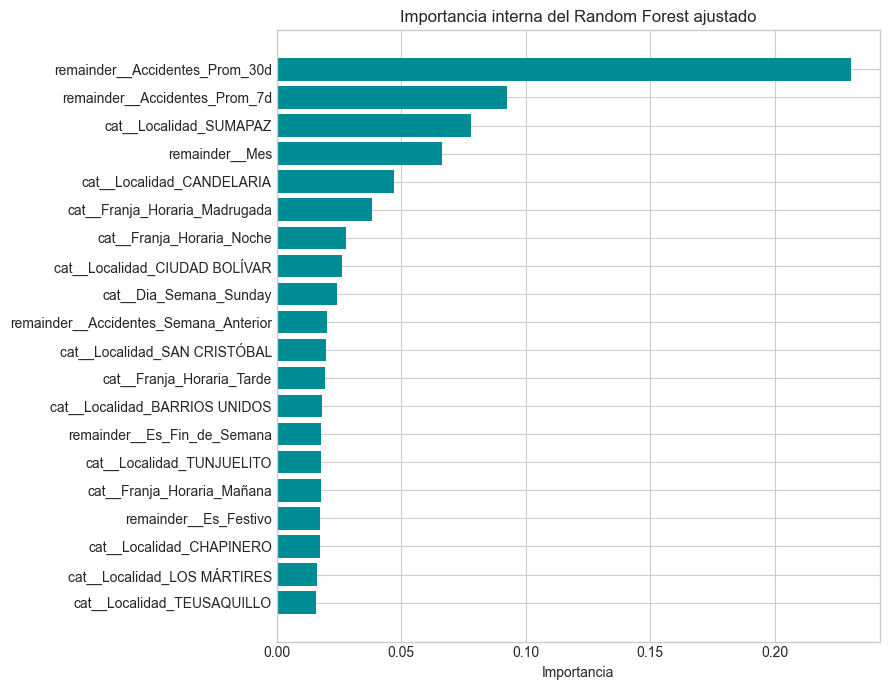

In [13]:
rf_pipeline = pipelines[selected_model]
transformed_names = rf_pipeline.named_steps['preprocesador'].get_feature_names_out()
internal_importance = pd.DataFrame({
    'Variable': transformed_names,
    'Importancia': rf_pipeline.named_steps['modelo'].feature_importances_
}).sort_values('Importancia', ascending=False)
internal_importance.to_csv(REPORTS_PATH / 'importancia_interna_random_forest_ajustado.csv', index=False, encoding='utf-8-sig')
display(internal_importance.head(20).round(4))
top = internal_importance.head(20).sort_values('Importancia')
plt.figure(figsize=(9,7)); plt.barh(top.Variable, top.Importancia, color='#008C95')
plt.title('Importancia interna del Random Forest ajustado'); plt.xlabel('Importancia'); plt.tight_layout()
plt.savefig(REPORTS_PATH / '06_importancia_interna_random_forest_ajustado.png', dpi=160, bbox_inches='tight'); plt.show()

## 11. Importancia por permutación

,Variable,Caida_AP_Media,Desviacion
0,Localidad,0.09921,0.00173
1,Franja_Horaria,0.06927,0.00717
2,Dia_Semana,0.01616,0.00286
7,Accidentes_Prom_30d,0.01310,0.00092
5,Es_Festivo,0.00590,0.00189
6,Accidentes_Prom_7d,0.00344,0.00147
4,Es_Fin_de_Semana,0.00191,0.00329
9,Sin_Historial_Accidentes_Prom_7d,0.00000,0.00000
10,Sin_Historial_Accidentes_Prom_30d,0.00000,0.00000
11,Sin_Historial_Accidentes_Semana_Anterior,0.00000,0.00000


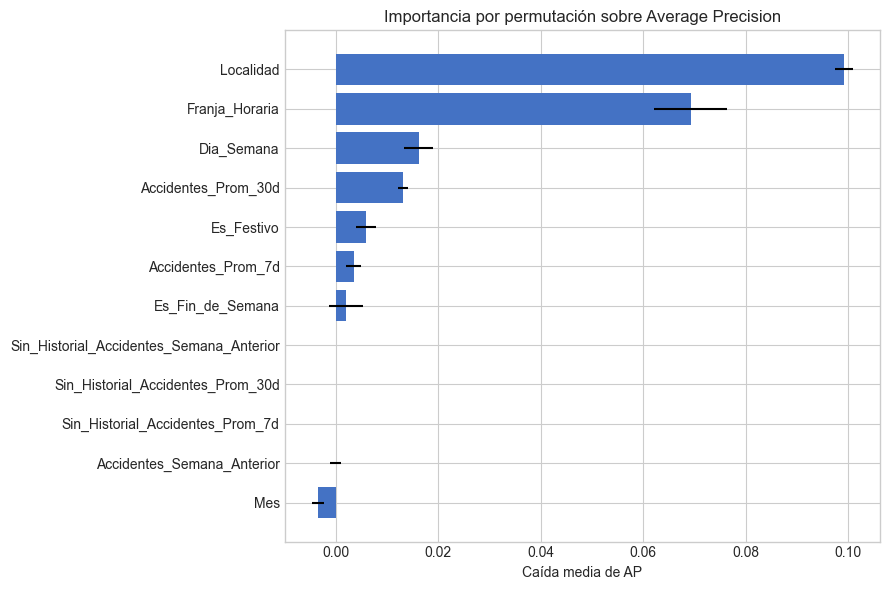

In [14]:
sample = test.sample(n=min(5000, len(test)), random_state=RANDOM_STATE)
permutation = permutation_importance(
    rf_pipeline, sample[feature_cols], sample.Alto_Riesgo,
    scoring='average_precision', n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1
)
permutation_table = pd.DataFrame({
    'Variable': feature_cols, 'Caida_AP_Media': permutation.importances_mean,
    'Desviacion': permutation.importances_std
}).sort_values('Caida_AP_Media', ascending=False)
permutation_table.to_csv(REPORTS_PATH / 'importancia_permutacion_random_forest_ajustado.csv', index=False, encoding='utf-8-sig')
display(permutation_table.round(5))
plot_perm = permutation_table.sort_values('Caida_AP_Media')
plt.figure(figsize=(9,6)); plt.barh(plot_perm.Variable, plot_perm.Caida_AP_Media, xerr=plot_perm.Desviacion, color='#4472C4')
plt.title('Importancia por permutación sobre Average Precision'); plt.xlabel('Caída media de AP')
plt.tight_layout(); plt.savefig(REPORTS_PATH / '07_importancia_permutacion.png', dpi=160, bbox_inches='tight'); plt.show()

La importancia interna y la permutación no representan causalidad ni porcentaje de accidentes explicado. Variables correlacionadas pueden compartir importancia; la permutación puede crear combinaciones poco realistas.

## 12. Brier frente a líneas base constantes

In [15]:
train_prevalence = dataset.loc[dataset.Periodo.eq('train'), 'Alto_Riesgo'].mean()
test_prevalence = y_test.mean()
constant_train = np.full(len(y_test), train_prevalence)
constant_oracle = np.full(len(y_test), test_prevalence)
brier_comparison = pd.DataFrame([
    {'Escenario': selected_model, 'Score_Medio': scores[selected_model].mean(),
     'Brier': brier_score_loss(y_test, scores[selected_model]),
     'AUC_ROC': roc_auc_score(y_test, scores[selected_model]),
     'Average_Precision': average_precision_score(y_test, scores[selected_model])},
    {'Escenario': 'Constante prevalencia train', 'Score_Medio': train_prevalence,
     'Brier': brier_score_loss(y_test, constant_train), 'AUC_ROC': 0.5,
     'Average_Precision': test_prevalence},
    {'Escenario': 'Constante prevalencia test (referencia retrospectiva)', 'Score_Medio': test_prevalence,
     'Brier': brier_score_loss(y_test, constant_oracle), 'AUC_ROC': 0.5,
     'Average_Precision': test_prevalence}
])
brier_comparison.to_csv(REPORTS_PATH / 'comparacion_brier_lineas_base.csv', index=False, encoding='utf-8-sig')
brier_comparison.round(4)

,Escenario,Score_Medio,Brier,AUC_ROC,Average_Precision
0,Random Forest ajustado,0.4574,0.2221,0.6933,0.3098
1,Constante prevalencia train,0.1705,0.1544,0.5000,0.1901
2,Constante prevalencia test (referencia retrosp...,0.1901,0.1540,0.5000,0.1901


Random Forest puede superar la referencia en AUC-ROC y Average Precision y, simultáneamente, obtener peor Brier. Esto significa que ordena los casos, pero sus valores crudos no representan bien las frecuencias observadas. La constante basada en test se incluye solo como referencia retrospectiva ideal y no estaría disponible al predecir el futuro.

## 13. Distribución de scores y volumen histórico por localidad

In [16]:
train = dataset[dataset.Periodo.eq('train')].copy()
historical_volume = train.groupby('Localidad').Num_Accidentes.sum().rename('Volumen_Historico_2018_2022')
score_summary = (rf_eval.groupby('Localidad').Score
                 .agg(Score_Min='min', Score_Medio='mean', Score_Mediana='median',
                      Score_P95=lambda x: x.quantile(.95), Score_Max='max').reset_index())
score_summary['Alertas_Umbral_Seleccionado'] = rf_eval.groupby('Localidad').Prediccion.sum().values
locality_diagnostic = (by_locality.merge(score_summary, on='Localidad')
                       .merge(historical_volume.reset_index(), on='Localidad'))
locality_diagnostic.to_csv(REPORTS_PATH / 'diagnostico_scores_localidad.csv', index=False, encoding='utf-8-sig')
locality_diagnostic.sort_values('Score_Max').round(4)

,Localidad,Observaciones,Positivos,Prevalencia,F1,AUC_ROC,Average_Precision,Precision,Recall,Especificidad,Balanced_Accuracy,Brier,Tasa_Predicha_Positiva,TN,FP,FN,TP,Score_Min,Score_Medio,Score_Mediana,Score_P95,Score_Max,Alertas_Umbral_Seleccionado,Volumen_Historico_2018_2022
18,SUMAPAZ,2924,2,0.0007,0.0000,0.3152,0.0007,0.0000,0.0000,1.0000,0.5000,0.0010,0.0000,2922,0,2,0,0.0034,0.0132,0.0090,0.0319,0.1965,0,8
19,CANDELARIA,2924,157,0.0537,0.0000,0.5673,0.0618,0.0000,0.0000,1.0000,0.5000,0.0656,0.0000,2767,0,157,0,0.0323,0.1665,0.1709,0.2618,0.3227,0,272
15,KENNEDY,2924,494,0.1689,0.2840,0.5909,0.2097,0.2258,0.3826,0.7333,0.5580,0.2189,0.2863,1782,648,305,189,0.1579,0.4470,0.4702,0.5872,0.6704,837,8246
17,CIUDAD BOLÍVAR,2924,323,0.1105,0.2000,0.6144,0.1845,0.2423,0.1703,0.9339,0.5521,0.1691,0.0776,2429,172,268,55,0.1563,0.3754,0.3626,0.5486,0.6887,227,3202
12,ANTONIO NARIÑO,2924,558,0.1908,0.3556,0.6083,0.2489,0.2331,0.7491,0.4189,0.5840,0.2608,0.6132,991,1375,140,418,0.1931,0.5165,0.5594,0.6518,0.7010,1793,1614
4,USME,2924,768,0.2627,0.4494,0.6017,0.3156,0.3093,0.8216,0.3465,0.5840,0.2648,0.6977,747,1409,137,631,0.2092,0.5382,0.5692,0.6555,0.7060,2040,1745
16,FONTIBÓN,2924,464,0.1587,0.2645,0.6017,0.2080,0.2018,0.3836,0.7138,0.5487,0.2205,0.3016,1756,704,286,178,0.1655,0.4507,0.4685,0.6086,0.7150,882,3748
10,TEUSAQUILLO,2924,489,0.1672,0.3896,0.6887,0.3049,0.3378,0.4601,0.8189,0.6395,0.1943,0.2278,1994,441,264,225,0.1447,0.4177,0.3927,0.6737,0.7194,666,2444
13,PUENTE ARANDA,2924,580,0.1984,0.3411,0.6082,0.2661,0.2490,0.5414,0.5960,0.5687,0.2435,0.4313,1397,947,266,314,0.2087,0.4943,0.5084,0.6317,0.7258,1261,4257
14,BOSA,2924,596,0.2038,0.3380,0.5758,0.2546,0.2589,0.4866,0.6435,0.5650,0.2496,0.3830,1498,830,306,290,0.2201,0.4998,0.5011,0.6470,0.7350,1120,4332


,Volumen_Historico_2018_2022,Prevalencia,Score_Medio,Recall,F1
Volumen_Historico_2018_2022,1.000,0.077,0.102,-0.065,-0.117
Prevalencia,0.077,1.000,0.925,0.911,0.876
Score_Medio,0.102,0.925,1.000,0.945,0.754
Recall,-0.065,0.911,0.945,1.000,0.865
F1,-0.117,0.876,0.754,0.865,1.000


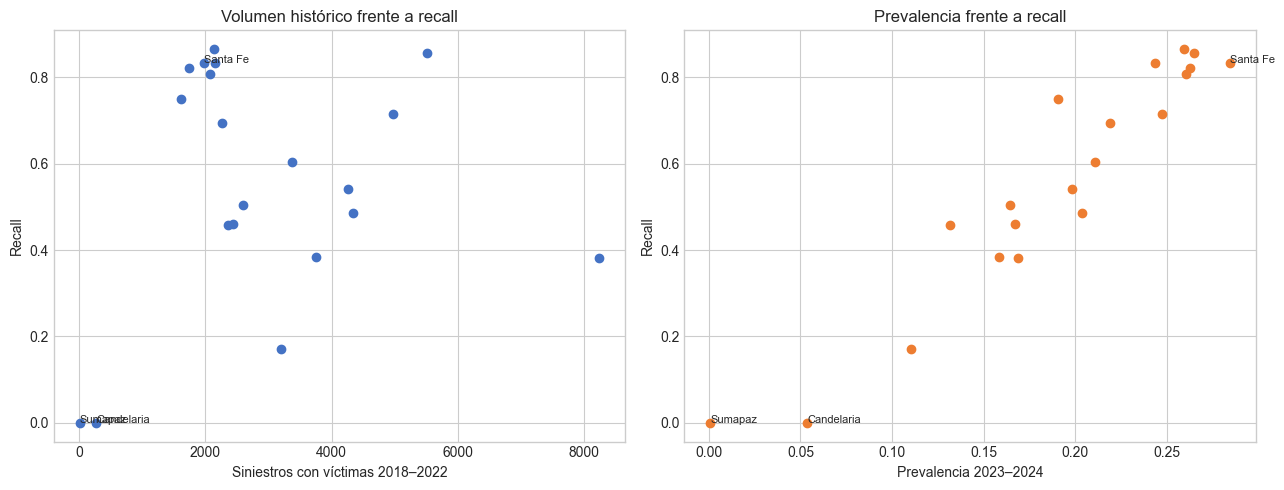

In [17]:
correlation_columns = ['Volumen_Historico_2018_2022','Prevalencia','Score_Medio','Recall','F1']
locality_correlations = locality_diagnostic[correlation_columns].corr(method='spearman')
locality_correlations.to_csv(REPORTS_PATH / 'correlaciones_spearman_localidad.csv', encoding='utf-8-sig')
display(locality_correlations.round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(locality_diagnostic.Volumen_Historico_2018_2022, locality_diagnostic.Recall, color='#4472C4')
axes[0].set(xlabel='Siniestros con víctimas 2018–2022', ylabel='Recall', title='Volumen histórico frente a recall')
axes[1].scatter(locality_diagnostic.Prevalencia, locality_diagnostic.Recall, color='#ED7D31')
axes[1].set(xlabel='Prevalencia 2023–2024', ylabel='Recall', title='Prevalencia frente a recall')
for _, row in locality_diagnostic.iterrows():
    if row.Localidad in ['CANDELARIA','SUMAPAZ','SANTA FE']:
        axes[0].annotate(row.Localidad.title(), (row.Volumen_Historico_2018_2022, row.Recall), fontsize=8)
        axes[1].annotate(row.Localidad.title(), (row.Prevalencia, row.Recall), fontsize=8)
plt.tight_layout(); plt.savefig(REPORTS_PATH / '08_volumen_prevalencia_recall.png', dpi=160, bbox_inches='tight')
plt.show()

La correlación entre volumen histórico y recall determina si el problema de Candelaria puede generalizarse. Una correlación cercana a cero impide afirmar que el modelo falle sistemáticamente en todas las localidades de bajo volumen; Candelaria y Sumapaz deben tratarse como casos críticos particulares.

## 14. Diagnóstico específico de Candelaria

In [18]:
candelaria = rf_eval[rf_eval.Localidad.eq('CANDELARIA')].copy()
candelaria_summary = pd.DataFrame([{
    'Observaciones': len(candelaria), 'Positivos': int(candelaria.Alto_Riesgo.sum()),
    'Prevalencia': candelaria.Alto_Riesgo.mean(), 'Score_Medio': candelaria.Score.mean(),
    'Score_Mediana': candelaria.Score.median(), 'Score_P95': candelaria.Score.quantile(.95),
    'Score_Max': candelaria.Score.max(),
    'Umbral_Global': selected_threshold, 'Alertas': int(candelaria.Prediccion.sum()),
    'TP': int(((candelaria.Alto_Riesgo == 1) & (candelaria.Prediccion == 1)).sum()),
    'Recall': recall_score(candelaria.Alto_Riesgo, candelaria.Prediccion, zero_division=0)
}])
candelaria_summary.to_csv(REPORTS_PATH / 'resumen_candelaria.csv', index=False, encoding='utf-8-sig')
candelaria_summary.round(4)

,Observaciones,Positivos,Prevalencia,Score_Medio,Score_Mediana,Score_P95,Score_Max,Umbral_Global,Alertas,TP,Recall
0,2924,157,0.0537,0.1665,0.1709,0.2618,0.3227,0.52,0,0,0.0


In [19]:
candelaria_threshold_rows = []
for threshold in np.linspace(0.05, selected_threshold, 95):
    pred = (candelaria.Score.to_numpy() >= threshold).astype(int)
    candelaria_threshold_rows.append({'Umbral': threshold,
        **classification_metrics(candelaria.Alto_Riesgo, pred, candelaria.Score)})
candelaria_thresholds = pd.DataFrame(candelaria_threshold_rows)
candelaria_best_threshold = float(candelaria_thresholds.loc[candelaria_thresholds.F1.idxmax(), 'Umbral'])
candelaria_thresholds.to_csv(REPORTS_PATH / 'diagnostico_umbral_candelaria.csv', index=False, encoding='utf-8-sig')

global_default = classification_metrics(y_test, predictions[selected_model], scores[selected_model])
global_low_pred = (scores[selected_model] >= candelaria_best_threshold).astype(int)
global_low = classification_metrics(y_test, global_low_pred, scores[selected_model])
targeted_pred = predictions[selected_model].copy()
cand_mask = test.Localidad.eq('CANDELARIA').to_numpy()
targeted_pred[cand_mask] = (scores[selected_model][cand_mask] >= candelaria_best_threshold).astype(int)
targeted = classification_metrics(y_test, targeted_pred, scores[selected_model])
threshold_impact = pd.DataFrame({
    f'Umbral global {selected_threshold:.2f}': global_default,
    f'Umbral global {candelaria_best_threshold:.3f}': global_low,
    f'Umbral {candelaria_best_threshold:.3f} solo Candelaria': targeted
}).T
threshold_impact.to_csv(REPORTS_PATH / 'impacto_umbral_candelaria.csv', encoding='utf-8-sig')
print(f'Umbral que maximiza F1 en Candelaria, calculado retrospectivamente: {candelaria_best_threshold:.3f}')
display(threshold_impact[['F1','Precision','Recall','FP','FN','TP','TN']].round(4))

Umbral que maximiza F1 en Candelaria, calculado retrospectivamente: 0.155


,F1,Precision,Recall,FP,FN,TP,TN
Umbral global 0.52,0.4058,0.2941,0.6544,17467.0,3842.0,7276.0,29895.0
Umbral global 0.155,0.3383,0.2038,0.9959,43259.0,46.0,11072.0,4103.0
Umbral 0.155 solo Candelaria,0.3927,0.2787,0.6648,19132.0,3727.0,7391.0,28230.0


El umbral específico se calcula sobre test y es solamente diagnóstico. No debe utilizarse en producción. Sirve para cuantificar cuántas falsas alertas aparecerían al intentar recuperar Candelaria mediante un umbral global y para motivar una futura selección de umbrales territoriales exclusivamente con validación temporal.

## 15. Calibración y Brier por localidad

In [20]:
train_prevalence_locality = train.groupby('Localidad').Alto_Riesgo.mean()
local_calibration_rows = []
for locality, part in rf_eval.groupby('Localidad'):
    local_base = float(train_prevalence_locality.loc[locality])
    local_calibration_rows.append({
        'Localidad': locality, 'Observaciones': len(part), 'Positivos': int(part.Alto_Riesgo.sum()),
        'Prevalencia_Train': local_base, 'Prevalencia_Test': part.Alto_Riesgo.mean(),
        'Score_Medio_RF': part.Score.mean(), 'Brier_RF': brier_score_loss(part.Alto_Riesgo, part.Score),
        'Brier_Constante_Train_Local': brier_score_loss(part.Alto_Riesgo, np.full(len(part), local_base))
    })
local_calibration = pd.DataFrame(local_calibration_rows)
local_calibration['Diferencia_Brier_RF_Menos_Base'] = (
    local_calibration.Brier_RF - local_calibration.Brier_Constante_Train_Local
)
local_calibration.to_csv(REPORTS_PATH / 'calibracion_por_localidad.csv', index=False, encoding='utf-8-sig')
local_calibration.sort_values('Diferencia_Brier_RF_Menos_Base', ascending=False).round(4)

,Localidad,Observaciones,Positivos,Prevalencia_Train,Prevalencia_Test,Score_Medio_RF,Brier_RF,Brier_Constante_Train_Local,Diferencia_Brier_RF_Menos_Base
17,TUNJUELITO,2924,713,0.2488,0.2438,0.5796,0.2942,0.1844,0.1098
0,ANTONIO NARIÑO,2924,558,0.1974,0.1908,0.5165,0.2608,0.1545,0.1064
6,ENGATIVÁ,2924,775,0.2444,0.2650,0.5887,0.2949,0.1952,0.0996
4,CHAPINERO,2924,758,0.2438,0.2592,0.5804,0.2902,0.1923,0.0980
7,FONTIBÓN,2924,464,0.1513,0.1587,0.4507,0.2205,0.1336,0.0870
2,BOSA,2924,596,0.1761,0.2038,0.4998,0.2496,0.1631,0.0865
9,LOS MÁRTIRES,2924,762,0.2378,0.2606,0.5670,0.2784,0.1932,0.0852
10,PUENTE ARANDA,2924,580,0.1728,0.1984,0.4943,0.2435,0.1597,0.0838
14,SUBA,2924,724,0.2082,0.2476,0.5393,0.2688,0.1878,0.0810
8,KENNEDY,2924,494,0.1442,0.1689,0.4470,0.2189,0.1410,0.0778


## 16. Volumen histórico y desempeño por franja

In [21]:
slot_volume = train.groupby('Franja_Horaria').Num_Accidentes.sum().rename('Volumen_Historico_2018_2022')
slot_scores = rf_eval.groupby('Franja_Horaria').Score.mean().rename('Score_Medio')
slot_diagnostic = by_slot.merge(slot_volume.reset_index(), on='Franja_Horaria').merge(slot_scores.reset_index(), on='Franja_Horaria')
slot_diagnostic.to_csv(REPORTS_PATH / 'diagnostico_volumen_franja.csv', index=False, encoding='utf-8-sig')
slot_diagnostic[['Franja_Horaria','Volumen_Historico_2018_2022','Prevalencia','Score_Medio','F1','Precision','Recall']].round(4)

,Franja_Horaria,Volumen_Historico_2018_2022,Prevalencia,Score_Medio,F1,Precision,Recall
0,Noche,15606,0.2252,0.5034,0.4306,0.3029,0.7442
1,Mañana,18934,0.1973,0.4755,0.4262,0.2980,0.7480
2,Tarde,18765,0.1794,0.4498,0.3957,0.2810,0.6687
3,Madrugada,5983,0.1585,0.4009,0.3330,0.2882,0.3943


La madrugada combina menor volumen histórico, menor score medio y menor recall. El patrón es compatible con una señal histórica más débil, pero cuatro franjas no permiten demostrar causalidad ni establecer una relación general entre volumen y desempeño.

## 17. Exportación de predicciones y conclusión ejecutiva

In [22]:
rf_eval.to_parquet(REPORTS_PATH / 'predicciones_random_forest_ajustado_2023_2024.parquet', index=False)
rf = global_metrics.set_index('Modelo').loc[selected_model]
rf_base = global_metrics.set_index('Modelo').loc['Random Forest base']
best_loc, worst_loc = by_locality.iloc[0], by_locality.iloc[-1]
best_slot, worst_slot = by_slot.iloc[0], by_slot.iloc[-1]
cand = by_locality.set_index('Localidad').loc['CANDELARIA']
executive = f"""# Conclusión ejecutiva del escenario con víctimas — modelo ajustado

El Random Forest ajustado, seleccionado exclusivamente con validación temporal 2020–2022 y umbral {selected_threshold:.2f}, obtiene retrospectivamente en 2023–2024 F1={rf.F1:.4f}, AUC-ROC={rf.AUC_ROC:.4f}, Average Precision={rf.Average_Precision:.4f}, precisión={rf.Precision:.2%} y recall={rf.Recall:.2%}. Detecta {int(rf.TP):,} positivos, genera {int(rf.FP):,} falsas alertas y omite {int(rf.FN):,} positivos.

Frente al Random Forest base, cambia el F1 en {rf.F1-rf_base.F1:+.4f}, el AUC-ROC en {rf.AUC_ROC-rf_base.AUC_ROC:+.4f}, la Average Precision en {rf.Average_Precision-rf_base.Average_Precision:+.4f} y el recall en {rf.Recall-rf_base.Recall:+.2%}. La mejora es modesta y debe leerse junto con el aumento de {int(rf.FP-rf_base.FP):,} falsas alertas.

El Brier del modelo ajustado es {rf.Brier:.4f}, frente a {brier_comparison.iloc[1].Brier:.4f} de la constante basada en la prevalencia de entrenamiento. Aunque mejora respecto al modelo base ({rf_base.Brier:.4f}), sigue siendo peor que la línea base: los scores sirven para ranking y priorización, no como probabilidades literales.

El desempeño territorial no es uniforme: {best_loc.Localidad} presenta el mayor F1 ({best_loc.F1:.4f}) y {worst_loc.Localidad} el menor ({worst_loc.F1:.4f}). Candelaria tiene {int(cand.Positivos)} positivos, {int(cand.TP)} detectados y recall {cand.Recall:.2%} con el umbral global. El umbral específico analizado para Candelaria es retrospectivo y no debe adoptarse sin validación futura.

Por franja, {best_slot.Franja_Horaria} obtiene el mayor F1 ({best_slot.F1:.4f}) y {worst_slot.Franja_Horaria} el menor ({worst_slot.F1:.4f}). La correlación de Spearman entre volumen histórico y recall es {locality_correlations.loc['Volumen_Historico_2018_2022','Recall']:.3f}; por tanto, el volumen no explica por sí solo las diferencias territoriales.

La etiqueta combina ocurrencia y superación de umbral según localidad y franja. Los resultados son retrospectivos, no causales ni confirmatorios. El sistema no está listo para producción sin evaluación futura independiente, calibración temporal y definición del costo operativo de falsas alertas y omisiones.
"""
(REPORTS_PATH / 'conclusion_ejecutiva.md').write_text(executive, encoding='utf-8')
print(executive)
print('Reportes guardados en:', REPORTS_PATH.resolve())

# Conclusión ejecutiva del escenario con víctimas — modelo ajustado

El Random Forest ajustado, seleccionado exclusivamente con validación temporal 2020–2022 y umbral 0.52, obtiene retrospectivamente en 2023–2024 F1=0.4058, AUC-ROC=0.6933, Average Precision=0.3098, precisión=29.41% y recall=65.44%. Detecta 7,276 positivos, genera 17,467 falsas alertas y omite 3,842 positivos.

Frente al Random Forest base, cambia el F1 en +0.0076, el AUC-ROC en +0.0080, la Average Precision en +0.0060 y el recall en +6.67%. La mejora es modesta y debe leerse junto con el aumento de 2,299 falsas alertas.

El Brier del modelo ajustado es 0.2221, frente a 0.1544 de la constante basada en la prevalencia de entrenamiento. Aunque mejora respecto al modelo base (0.2304), sigue siendo peor que la línea base: los scores sirven para ranking y priorización, no como probabilidades literales.

El desempeño territorial no es uniforme: SANTA FE presenta el mayor F1 (0.4834) y CANDELARIA el menor (0.0000). Candelaria 